# 📡 Chapter 5: Information Theory

## *From "how much does a message surprise you?" to the limits of communication*

---

### The Question Shannon Asked

In 1948, Claude Shannon published a paper that created an entirely new field.
He was working at Bell Labs, trying to understand telephone and telegraph
systems, and he asked a deceptively simple question:

> **What is information — and how do you measure it?**

His answer unified cryptography, communications, statistics, and — decades
later — machine learning. The same mathematics that tells you how many bits
it takes to compress English text also explains why Enigma was breakable,
why neural networks use cross-entropy loss, and how JPEG compression works.

We already met one piece of this theory in Chapter 4: **Turing's bans**.
Turing's weight-of-evidence scale, invented independently at Bletchley Park,
is equivalent to Shannon information up to a constant factor (1 ban ≈ 3.32 bits).
Shannon formalised and generalised it.

## Part 1: Entropy — Measuring Surprise

What does it mean for a message to contain information?

Intuitively, *surprising* events carry more information than *expected* ones.
"The sun rose this morning" tells you almost nothing. "Bletchley Park broke
Enigma in three hours using a single crib" would be astonishing.

Shannon captured this with a simple formula. If an event has probability $p$,
its **information content** (or *surprisal*) is:

$$I(x) = -\log_2 p(x) \quad \text{bits}$$

A coin flip ($p = 0.5$) carries $-\log_2(0.5) = 1$ bit of information.
A certain event ($p = 1.0$) carries $0$ bits. A very rare event ($p = 0.01$)
carries $\approx 6.6$ bits.

**Shannon entropy** is the *expected* surprisal — the average information
content per symbol drawn from a source:

$$H(X) = -\sum_{x} p(x) \log_2 p(x) \quad \text{bits per symbol}$$

This is the same formula as Turing's bans (Chapter 4), with $\log_2$ instead
of $\log_{10}$ and a different sign convention.  Entropy is the average number
of bits you need to encode one symbol from the source.

In [1]:
import sys
sys.path.insert(0, '..')

import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src.information_theory.entropy import entropy, entropy_from_freqs, ENGLISH_FREQUENCIES

# Three very different texts
examples = {
    "English":   "THE QUICK BROWN FOX JUMPS OVER THE LAZY DOG",
    "Random":    "XKQZJVBWPYFUHMOLCNRSDTIGEAXKQZJVBWPYFUHMO",
    "Repetitive": "A" * 50,
}

print("Shannon entropy (bits per letter):")
print("-" * 40)
for name, text in examples.items():
    h = entropy(text)
    print(f"  {name:<12} {h:.4f} bits")

print()
print(f"  Theoretical max for 26 letters: {math.log2(26):.4f} bits")
print(f"  English frequencies (full):     {entropy_from_freqs(ENGLISH_FREQUENCIES):.4f} bits")

Matplotlib is building the font cache; this may take a moment.


Shannon entropy (bits per letter):
----------------------------------------
  English      4.5363 bits
  Random       4.6258 bits
  Repetitive   -0.0000 bits

  Theoretical max for 26 letters: 4.7004 bits
  English frequencies (full):     4.1717 bits


### What those numbers mean

- **Repetitive text** (`AAAA…`): entropy = 0. You already know every symbol.
  No compression needed — or possible.
- **Random text**: entropy ≈ 4.7 bits. Letters approach uniform distribution.
  Hard to compress.
- **English**: entropy ≈ 4.1 bits. Structured, but not uniform.
  You can compress English — ZIP files work because of this structure.

The **theoretical maximum** for a 26-letter alphabet is $\log_2(26) \approx 4.70$ bits,
achieved only when all 26 letters are equally likely.

Real English uses some letters far more than others (E at 12.7%, Z at 0.07%),
so its entropy is lower.  That structure is exactly what the Bayesian decoder
in Chapter 3 exploited: improbable letter frequencies eliminated wrong
Enigma settings.

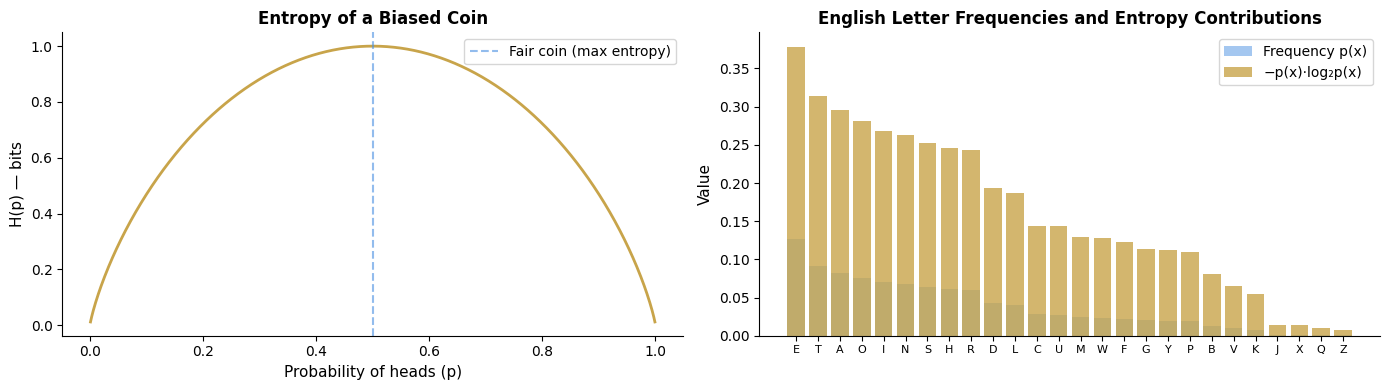

Total entropy (sum of contributions): 4.1717 bits


In [2]:
# Visualise entropy as a function of bias for a two-symbol source
p_values = np.linspace(0.001, 0.999, 1000)
h_values = -(p_values * np.log2(p_values) + (1 - p_values) * np.log2(1 - p_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: entropy of a biased coin
ax = axes[0]
ax.plot(p_values, h_values, color='#c8a44a', linewidth=2)
ax.axvline(0.5, color='#4a90e2', linestyle='--', alpha=0.6, label='Fair coin (max entropy)')
ax.set_xlabel('Probability of heads (p)', fontsize=11)
ax.set_ylabel('H(p) — bits', fontsize=11)
ax.set_title('Entropy of a Biased Coin', fontsize=12, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: letter frequency vs entropy contribution for English
ax = axes[1]
letters = sorted(ENGLISH_FREQUENCIES, key=lambda l: -ENGLISH_FREQUENCIES[l])
total = sum(ENGLISH_FREQUENCIES.values())
probs = [ENGLISH_FREQUENCIES[l] / total for l in letters]
contributions = [-p * math.log2(p) for p in probs]

x = range(len(letters))
ax.bar(x, probs, color='#4a90e2', alpha=0.5, label='Frequency p(x)')
ax.bar(x, contributions, color='#c8a44a', alpha=0.8, label='−p(x)·log₂p(x)')
ax.set_xticks(list(x))
ax.set_xticklabels(letters, fontsize=8)
ax.set_title('English Letter Frequencies and Entropy Contributions', fontsize=12, fontweight='bold')
ax.set_ylabel('Value', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print(f"Total entropy (sum of contributions): {sum(contributions):.4f} bits")

## Part 2: Source Coding — The Entropy Floor

Shannon's **source coding theorem** (also called the noiseless coding theorem)
says something remarkable:

> You can compress a source to an average of $H$ bits per symbol, but *no
> further*.

This is a hard lower bound. No matter how clever your compression algorithm,
you cannot do better than entropy on average.

The question then is: can we *reach* the entropy floor?  Yes — and David
Huffman showed how, in 1952, as a term paper for his MIT information theory
course.

**Huffman's idea**: assign shorter bit-strings to frequent symbols and longer
ones to rare symbols, building a binary tree greedily from the bottom up.
The resulting code is guaranteed to be within 1 bit per symbol of the entropy
floor.

This is exactly the logic behind modern compression (ZIP, DEFLATE) and image
formats (JPEG, PNG).  It's also why Morse code gives E a single dot (•) and
Q four symbols (- - • -).

In [3]:
from src.information_theory.coding import build_tree, build_codes, average_code_length
from src.information_theory.entropy import entropy_from_freqs, ENGLISH_FREQUENCIES

tree  = build_tree(ENGLISH_FREQUENCIES)
codes = build_codes(tree)

# Sort by code length for display
sorted_codes = sorted(codes.items(), key=lambda kv: (len(kv[1]), kv[0]))

print("Huffman codes for English letters (sorted by length):\n")
print(f"  {'Letter':<8} {'Code':<16} {'Length':>6}  {'Frequency':>10}")
print("  " + "-" * 46)
for sym, code in sorted_codes:
    freq = ENGLISH_FREQUENCIES.get(sym, 0)
    print(f"  {sym:<8} {code:<16} {len(code):>6}  {freq:>9.2f}%")

avg  = average_code_length(codes, ENGLISH_FREQUENCIES)
h    = entropy_from_freqs(ENGLISH_FREQUENCIES)
print(f"\nEntropy floor:        {h:.4f} bits/letter")
print(f"Average code length:  {avg:.4f} bits/letter")
print(f"Overhead above floor: {avg - h:.4f} bits  (Huffman guarantees < 1.0)")

Huffman codes for English letters (sorted by length):

  Letter   Code             Length   Frequency
  ----------------------------------------------
  E        100                   3      12.70%
  T        000                   3       9.06%
  A        1110                  4       8.17%
  H        0110                  4       6.09%
  I        1011                  4       6.97%
  N        1010                  4       6.75%
  O        1101                  4       7.51%
  R        0101                  4       5.99%
  S        0111                  4       6.33%
  C        01001                 5       2.78%
  D        11111                 5       4.25%
  F        00101                 5       2.23%
  L        11110                 5       4.03%
  M        00111                 5       2.41%
  U        01000                 5       2.76%
  W        00110                 5       2.36%
  B        110000                6       1.29%
  G        110011                6       2.02%
  P

### Reading the table

- **E** (12.7%) gets a short code — it appears constantly, so saving bits here pays off.
- **Z** (0.07%) gets a long code — it's so rare that the extra bits barely cost anything
  in expectation.
- The average code length should be very close to the entropy floor (~4.17 bits),
  confirming Huffman's guarantee.

This also connects to the Enigma story: the reason the Bayesian decoder works
at all is that English has this structure.  If all 26 letters were equally likely
(entropy = 4.70 bits), each Enigma setting would look equally plausible and
no Bayesian update would help.

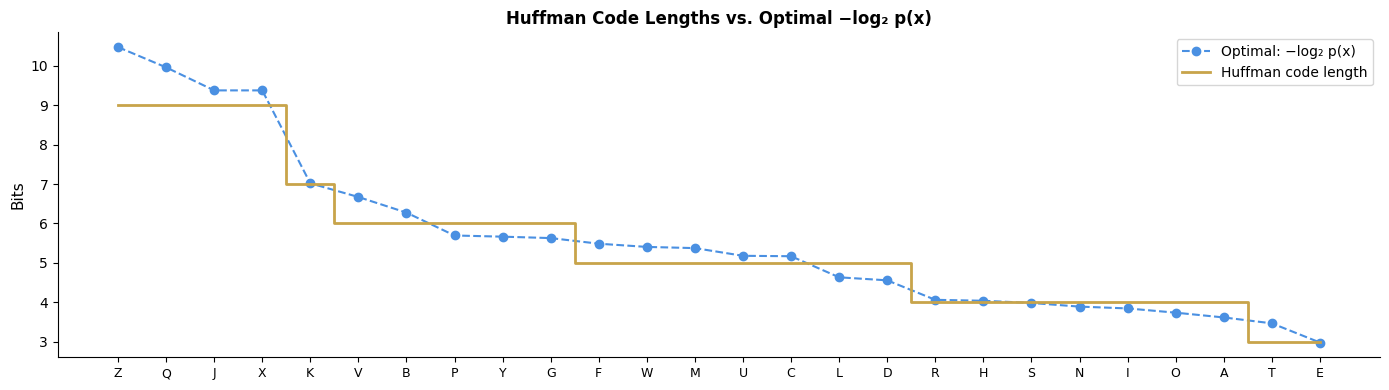

In [4]:
# Visualise: code length vs log₂(1/p) — Huffman should track this closely
total = sum(ENGLISH_FREQUENCIES.values())
letters_sorted = sorted(ENGLISH_FREQUENCIES, key=lambda l: ENGLISH_FREQUENCIES[l])

optimal_lengths = [-math.log2(ENGLISH_FREQUENCIES[l] / total) for l in letters_sorted]
huffman_lengths = [len(codes[l]) for l in letters_sorted]

fig, ax = plt.subplots(figsize=(14, 4))
x = range(len(letters_sorted))
ax.plot(list(x), optimal_lengths, 'o--', color='#4a90e2', label='Optimal: −log₂ p(x)', linewidth=1.5)
ax.step(list(x), huffman_lengths, where='mid', color='#c8a44a', label='Huffman code length', linewidth=2)
ax.set_xticks(list(x))
ax.set_xticklabels(letters_sorted, fontsize=9)
ax.set_ylabel('Bits', fontsize=11)
ax.set_title('Huffman Code Lengths vs. Optimal −log₂ p(x)', fontsize=12, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Part 3: Noisy Channels and Channel Capacity

So far we've assumed a perfect channel: whatever you send is received exactly.
Real channels — telegraph wires, radio links, the internet — introduce errors.

Shannon's **channel coding theorem** addresses this.  The simplest model is
the **Binary Symmetric Channel (BSC)**: each transmitted bit is independently
flipped with probability $p$.

Shannon proved that every channel has a **capacity** $C$ (in bits per use),
and:

- If you transmit *below* capacity, errors can be made arbitrarily rare by
  using a clever enough code.
- If you transmit *above* capacity, errors are unavoidable no matter what.

For the BSC with flip probability $p$:

$$C = 1 - H_b(p) = 1 + p \log_2 p + (1 - p) \log_2 (1 - p)$$

where $H_b(p)$ is the **binary entropy function** — the entropy of a biased
coin with heads probability $p$.

At $p = 0$ (perfect channel): $C = 1$ bit/use.
At $p = 0.5$ (pure noise, useless channel): $C = 0$ bits/use.

In [5]:
import random
from src.information_theory.channel import (
    bsc_channel, encode_repetition, decode_repetition, bsc_capacity
)

random.seed(42)

# Generate 200 random bits
message = [random.randint(0, 1) for _ in range(200)]

error_rate = 0.10  # 10% of bits flipped

# ── Uncoded transmission ──────────────────────────────────────────────────────
received_raw = bsc_channel(message, error_rate)
raw_errors   = sum(a != b for a, b in zip(message, received_raw))

# ── Rate-1/3 repetition code (each bit sent 3 times, majority vote) ───────────
encoded        = encode_repetition(message, n=3)
received_coded = bsc_channel(encoded, error_rate)
decoded        = decode_repetition(received_coded, n=3)
coded_errors   = sum(a != b for a, b in zip(message, decoded))

print("Transmission results (200 bits, error_rate=0.10):\n")
print(f"  Without coding:    {raw_errors:3d} / 200 bit errors  ({100*raw_errors/200:.1f}%)")
print(f"  Repetition code:   {coded_errors:3d} / 200 bit errors  ({100*coded_errors/200:.1f}%)")
print()
print(f"  BSC capacity at p=0.10: {bsc_capacity(0.10):.4f} bits per channel use")
print(f"  Repetition code rate:   0.333 bits per channel use  (< capacity, so reliable is achievable)")

Transmission results (200 bits, error_rate=0.10):

  Without coding:     16 / 200 bit errors  (8.0%)
  Repetition code:     5 / 200 bit errors  (2.5%)

  BSC capacity at p=0.10: 0.5310 bits per channel use
  Repetition code rate:   0.333 bits per channel use  (< capacity, so reliable is achievable)


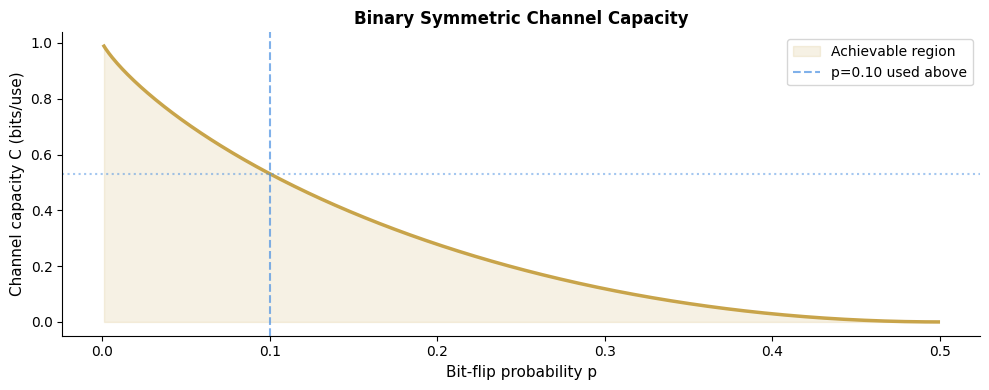

In [6]:
# Plot BSC capacity as a function of error rate
p_values = np.linspace(0.001, 0.499, 500)
c_values = [bsc_capacity(p) for p in p_values]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(p_values, c_values, color='#c8a44a', linewidth=2.5)
ax.fill_between(p_values, c_values, alpha=0.15, color='#c8a44a', label='Achievable region')
ax.axvline(0.10, color='#4a90e2', linestyle='--', alpha=0.7, label='p=0.10 used above')
ax.axhline(bsc_capacity(0.10), color='#4a90e2', linestyle=':', alpha=0.5)
ax.set_xlabel('Bit-flip probability p', fontsize=11)
ax.set_ylabel('Channel capacity C (bits/use)', fontsize=11)
ax.set_title('Binary Symmetric Channel Capacity', fontsize=12, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### The repetition code is simple but wasteful

Our rate-1/3 repetition code (send each bit three times, take majority vote)
reduces errors — but at the cost of transmitting three times as many bits.

Shannon showed there exist codes that approach capacity $C$ with error rates
approaching zero, without sacrificing that much bandwidth.  Modern codes
(Turbo codes, LDPC, Polar codes) essentially achieve this theoretical limit.

The intuition is the same as Bayesian updating: accumulate many weak pieces
of evidence until confidence is arbitrarily high.  The repetition code is the
brute-force version; modern codes are the Turing/Bayes version.

## Part 4: Information Theory Today

Shannon's entropy appears throughout modern machine learning — often under
different names.

| ML concept | Information theory connection |
|---|---|
| **Cross-entropy loss** | $H(p, q) = -\sum p(x) \log q(x)$ — measures how well a model distribution $q$ approximates the true distribution $p$ |
| **KL divergence** | $D_{KL}(p \| q) = H(p, q) - H(p)$ — the "extra bits" you waste by using the wrong model |
| **Perplexity** | $2^{H(p, q)}$ — entropy in a more human-readable form; lower is better |
| **Turing's bans** (Chapter 4) | $1 \text{ ban} = \log_{10} 10 = 1/\log_2 10 \approx 0.301 \text{ bits}$ |
| **Mutual information** | $I(X; Y) = H(X) - H(X \mid Y)$ — how much knowing $Y$ reduces uncertainty about $X$ |

The cross-entropy loss used to train GPT-4 is mathematically identical to
asking: how many bits does the model need to encode the next token, given
the context?  Training minimises this, pushing the model's distribution
toward the true distribution of language.

In [7]:
def cross_entropy(true_probs: dict, model_probs: dict) -> float:
    """H(p, q) = -∑ p(x) log₂ q(x)"""
    total_p = sum(true_probs.values())
    total_q = sum(model_probs.values())
    return -sum(
        (true_probs[x] / total_p) * math.log2((model_probs[x] / total_q))
        for x in true_probs
        if true_probs[x] > 0 and model_probs.get(x, 0) > 0
    )

def kl_divergence(true_probs: dict, model_probs: dict) -> float:
    """D_KL(p ‖ q) = H(p, q) - H(p)"""
    return cross_entropy(true_probs, model_probs) - entropy_from_freqs(true_probs)

# Scenario: true English letter distribution vs. a model's prediction
true_dist  = ENGLISH_FREQUENCIES

# Model A: knows English frequencies well
model_good = {k: v + 0.2 for k, v in ENGLISH_FREQUENCIES.items()}  # slight noise

# Model B: uniform distribution (knows nothing)
model_uniform = {k: 1.0 for k in ENGLISH_FREQUENCIES}

h_true = entropy_from_freqs(true_dist)
print(f"True entropy H(p):                      {h_true:.4f} bits")
print()
print(f"Cross-entropy H(p, good_model):         {cross_entropy(true_dist, model_good):.4f} bits")
print(f"KL divergence D_KL(p ‖ good_model):     {kl_divergence(true_dist, model_good):.4f} bits")
print()
print(f"Cross-entropy H(p, uniform_model):      {cross_entropy(true_dist, model_uniform):.4f} bits")
print(f"KL divergence D_KL(p ‖ uniform_model):  {kl_divergence(true_dist, model_uniform):.4f} bits")
print()
print("The uniform model wastes more bits — it doesn't know that E is more")
print("likely than Z.  Training a language model minimises this KL divergence.")

True entropy H(p):                      4.1717 bits

Cross-entropy H(p, good_model):         4.1770 bits
KL divergence D_KL(p ‖ good_model):     0.0053 bits

Cross-entropy H(p, uniform_model):      4.7004 bits
KL divergence D_KL(p ‖ uniform_model):  0.5287 bits

The uniform model wastes more bits — it doesn't know that E is more
likely than Z.  Training a language model minimises this KL divergence.


## Summary

Shannon information theory gives us a unified language for uncertainty,
compression, and communication:

$$H(X) = -\sum_x p(x) \log_2 p(x)$$

Key results:

1. **Entropy lower-bounds compression**: no lossless code beats $H$ bits/symbol
   on average (source coding theorem).

2. **Huffman coding** reaches within 1 bit of this floor using a greedy
   binary tree built from symbol frequencies.

3. **Channel capacity** sets the ultimate limit on reliable communication
   over a noisy channel — regardless of the error-correction scheme used.

4. **Cross-entropy loss** in ML is entropy in disguise: training a model to
   minimise it is equivalent to minimising $D_{KL}(p_{data} \| p_{model})$.

5. **Turing's bans** (Chapter 4) are Shannon bits scaled by $\log_2 10 / 1$:
   the two frameworks are the same mathematics, invented independently for
   the same purpose — reasoning under uncertainty.